# Sample buildings and surrounding context

This notebook draws the building sample the rest of the pipeline is built on. For every requested
building type it picks real OSM footprints, spread across cities in proportion to population, keeps
the ones whose geometry can become a usable energy model, and collects the neighbouring buildings
that shade them.

Residential buildings are classified from the GHSL Built-C class under their centroid;
non-residential ones from their OSM tags. After that both follow the same path, in one table with a
`dataset_kind` column telling them apart.

Sampling is random but seeded, so the same request produces the same buildings on every run.

**Inputs**

- `data/interim/cities_df.pkl` and `data/interim/city_assets_df.pkl` from `BEM4AI_1_Cities.ipynb`
- the per-city OSM extracts and GHSL Built-C, Built-H and Built-Age chips those notebooks produced

**Outputs**

- `data/interim/buildings_gdf.pkl` - one row per sampled building
- `data/interim/neighbors_gdf.pkl` - the surrounding footprints, keyed by `sample_id`

## Setup

**Steps**

1. Import the libraries and the Stage 3 helpers, and resolve the source directories.
2. Load the two Stage 1 city tables and join the population onto the asset registry.
3. Keep the cities that have a population and every mandatory source file.

**Outputs**
`cities_df`, `city_assets_df`, and `city_pool` - the cities this stage may sample from.


In [1]:
import warnings
import contextlib
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from pyproj import CRS
from tqdm import TqdmWarning, tqdm

warnings.filterwarnings("ignore", message="IProgress not found.*", category=TqdmWarning)

from helpers.GHSL_gridplot import GHSL_gridplot
from helpers.building_sampling import (
    FootprintLimits,
    NeighborSearch,
    WGS84,
    allocate_by_population,
    assign_sample_ids,
    build_neighbors,
    filter_footprints,
    load_city_buildings,
    make_source_sample_id,
    sample_rasters_at_point,
)
from helpers.config import load_json_config
from helpers.paths import DATA_DIR, INTERIM_DIR, display_path
from helpers.utils import (
    as_int_or_none,
    concat_gdfs,
    empty_gdf,
    metric_crs_for_gdf,
    metric_crs_for_row,
)

PBF_DIR = DATA_DIR / "OSM PBF" / "cities_osm_pbf"
BUILTC_DIR = DATA_DIR / "GHS_BuiltC_cities"
BUILTH_DIR = DATA_DIR / "GHS_BuiltH_cities"
BUILTAGE_DIR = DATA_DIR / "GHS_BuiltAge_cities"

CITIES_PKL = INTERIM_DIR / "cities_df.pkl"
CITY_ASSETS_PKL = INTERIM_DIR / "city_assets_df.pkl"

missing = [path for path in (CITIES_PKL, CITY_ASSETS_PKL) if not path.exists()]
if missing:
    raise FileNotFoundError(
        f"Missing {', '.join(display_path(path) for path in missing)}. "
        "Run BEM4AI_1_Cities.ipynb first."
    )

cities_df = pd.read_pickle(CITIES_PKL)
city_assets_df = pd.read_pickle(CITY_ASSETS_PKL)

# Population decides how many buildings each city contributes.
population = (
    cities_df[["city_key", "GC_POP_TOT_2025"]]
    .drop_duplicates("city_key")
    .assign(population=lambda frame: pd.to_numeric(frame["GC_POP_TOT_2025"], errors="coerce"))
    [["city_key", "population"]]
)
city_pool = city_assets_df.merge(population, on="city_key", how="left", validate="one_to_one")

# Built-Age is optional; a city without it still yields buildings, just without an age value.
REQUIRED_ASSETS = {"osm_pbf": PBF_DIR, "builtc_tif": BUILTC_DIR, "builth_tif": BUILTH_DIR}


def has_every_asset(row: pd.Series) -> bool:
    for column, directory in REQUIRED_ASSETS.items():
        name = row.get(column)
        if not isinstance(name, str) or not (directory / Path(name).name).is_file():
            return False
    return pd.notna(row.get("population")) and float(row["population"]) > 0


usable = city_pool.apply(has_every_asset, axis=1)
if (~usable).any():
    print(f"Skipping {(~usable).sum()} cities without a population or a complete set of source files")

city_pool = (
    city_pool.loc[usable]
    .sort_values(["population", "city_key"], ascending=[False, True])
    .reset_index(drop=True)
)
if city_pool.empty:
    raise ValueError("No city has a population and every mandatory Stage 3 asset.")

city_pool_by_key = city_pool.set_index("city_key", drop=False)
cities_by_key = cities_df.drop_duplicates("city_key").set_index("city_key", drop=False)

print(f"{len(city_pool)} cities eligible across {city_pool['country'].nunique()} countries")
city_pool[["city_key", "country", "population"]].head()

745 cities eligible across 27 countries


,city_key,country,population
0,London,United Kingdom,1.040833e+07
1,Paris,France,9.328385e+06
2,Madrid,Spain,5.680137e+06
3,Barcelona,Spain,3.908362e+06
4,Berlin,Germany,3.549997e+06


## Configure the requested sample

Set how many buildings of each type to draw. A type can be switched off with `0`, and either whole
group - residential or non-residential - can be dropped that way.

The total is spread across the eligible cities in proportion to population, by largest remainders.
A small request therefore lands in the largest cities; as the request grows, smaller cities join
while the proportions hold. The type slots are then shuffled across the city slots with
`RANDOM_SEED`, so the request is reproducible without being ordered by type.

**Outputs**
The request, the quality thresholds every later cell reads, and the metric-CRS helper.


In [2]:
BUILDING_TYPE_CONFIG = load_json_config("building_types.json")
BUILDING_TYPES = BUILDING_TYPE_CONFIG["building_types"]

# GHSL Built-C class -> residential type; OSM tags decide the non-residential ones further down.
RES_CLASS_TO_BUILDING_TYPE = {
    int(value): label
    for value, label in BUILDING_TYPE_CONFIG["ghsl_builtc_to_sampling_label"].items()
}
BUILDING_TYPE_TO_ID = {entry["sampling_label"]: int(entry["id"]) for entry in BUILDING_TYPES}
NONRES_TYPES = {entry["sampling_label"] for entry in BUILDING_TYPES if entry["sector"] == "Service"}

TARGET_BUILDING_TYPES = {
    "SF_TERRACED": 3,
    "MULTIFAMILY": 3,
    "APARTMENT_BLOCK": 3,
    "Offices": 3,
    "Trade": 2,
    "Education": 2,
    "Health": 2,
    "HotelsRestaurants": 2,
}

RANDOM_SEED = 21370
MAX_SAMPLING_PASSES = 6

# What a footprint has to look like to be worth modelling.
FOOTPRINT_LIMITS = FootprintLimits(
    area_min_m2=20.0,
    area_max_m2=2000.0,
    max_holes=4,
    max_exterior_vertices=64,
    sliver_max_width_m=2.0,
    sliver_min_aspect_ratio=8.0,
)

# How far to look for buildings that shade a sample, and when a candidate is the sample itself.
NEIGHBOR_SEARCH = NeighborSearch(radius_m=20.0, overlap_area_eps_m2=0.5)

ENABLE_QA_PLOTS = True
QA_PLOT_SAMPLES = 20
QA_PLOT_COLUMNS = 5

unknown = sorted(set(TARGET_BUILDING_TYPES) - set(BUILDING_TYPE_TO_ID))
if unknown:
    raise ValueError(f"Unknown building types requested: {unknown}")

requested_by_type = {name: int(count) for name, count in TARGET_BUILDING_TYPES.items() if int(count) > 0}
if not requested_by_type:
    raise ValueError("Request at least one building by setting a target above zero.")


def metric_crs_for_city(city_key, fallback_gdf: gpd.GeoDataFrame | None = None) -> CRS:
    """The projected CRS a city's metres are measured in, from its coordinates."""
    city_key = str(city_key)
    if city_key in cities_by_key.index:
        return metric_crs_for_row(cities_by_key.loc[city_key])
    if fallback_gdf is not None and not fallback_gdf.empty:
        return metric_crs_for_gdf(fallback_gdf)
    raise KeyError(f"No metric CRS for city {city_key!r}")


print(f"Requested {sum(requested_by_type.values())} buildings: {requested_by_type}")

Requested 20 buildings: {'SF_TERRACED': 3, 'MULTIFAMILY': 3, 'APARTMENT_BLOCK': 3, 'Offices': 3, 'Trade': 2, 'Education': 2, 'Health': 2, 'HotelsRestaurants': 2}


## Allocate the request across cities

**Steps**

1. Split the total across the eligible cities in proportion to population.
2. Turn the allocation into one slot per building, and shuffle the requested types across those slots.
3. Count the slots back up into a plan of `city_key` x `building_type` targets.

**Outputs**
`sampling_plan`, and `retry_plan_for`, which re-allocates whatever a pass could not find.


In [3]:
def build_sampling_plan(cities: pd.DataFrame, type_targets: dict[str, int], seed: int) -> pd.DataFrame:
    """One target per city and building type, population-weighted and reproducible."""
    city_slots = [
        str(city_key)
        for city_key, count in allocate_by_population(sum(type_targets.values()), cities).items()
        for _ in range(int(count))
    ]
    type_slots = [name for name, count in type_targets.items() for _ in range(int(count))]
    if len(city_slots) != len(type_slots):
        raise RuntimeError("City and building-type slot counts do not agree.")

    # Shuffling the types decouples the request order from the city order.
    np.random.default_rng(seed).shuffle(type_slots)
    return (
        pd.DataFrame({"city_key": city_slots, "building_type": type_slots})
        .groupby(["city_key", "building_type"], as_index=False)
        .size()
        .rename(columns={"size": "target"})
    )


def retry_plan_for(shortfall: pd.Series, cities: pd.DataFrame, exhausted: set) -> pd.DataFrame:
    """Re-allocate what is still missing, skipping city and type pairs already tried."""
    parts = []
    for building_type, remaining in shortfall.items():
        if int(remaining) <= 0:
            continue
        eligible = cities.loc[
            ~cities["city_key"].astype(str).map(
                lambda key: (key, str(building_type)) in exhausted
            )
        ]
        allocation = allocate_by_population(int(remaining), eligible)
        part = allocation.loc[allocation > 0].rename("target").reset_index()
        if not part.empty:
            parts.append(part.assign(building_type=str(building_type))[
                ["city_key", "building_type", "target"]])
    if not parts:
        return pd.DataFrame(columns=["city_key", "building_type", "target"])
    return pd.concat(parts, ignore_index=True)


sampling_plan = build_sampling_plan(city_pool, requested_by_type, RANDOM_SEED)

plan_summary = (
    sampling_plan.groupby("city_key", as_index=False)["target"].sum()
    .merge(city_pool[["city_key", "country", "population"]], on="city_key", how="left")
    .sort_values(["target", "population", "city_key"], ascending=[False, False, True])
)
print(f"Plan: {sampling_plan['target'].sum()} buildings across {len(plan_summary)} cities")
plan_summary.head(15)

Plan: 20 buildings across 20 cities


,city_key,target,country,population
9,London,1,United Kingdom,1.040833e+07
15,Paris,1,France,9.328385e+06
10,Madrid,1,Spain,5.680137e+06
1,Barcelona,1,Spain,3.908362e+06
2,Berlin,1,Germany,3.549997e+06
0,Athens,1,Greece,3.166757e+06
12,Milan,1,Italy,3.135553e+06
14,Naples,1,Italy,2.885079e+06
6,Essen,1,Germany,2.718996e+06
3,Birmingham,1,United Kingdom,2.617211e+06


## Classify a building from its tags

A building is non-residential when its OSM tags say so: an `office` tag, a `shop`, an `amenity` of
the right kind. The first rule that matches wins, so the order below is the priority order.

Anything that carries no such tag is treated as residential and typed from the GHSL Built-C class
under its centroid, which distinguishes terraced houses, multi-family buildings and apartment
blocks by height in a way OSM tags do not.

**Outputs**
`classify_service_type` and `looks_non_residential`, which the sampler calls per building.


In [4]:
SERVICE_OSM = BUILDING_TYPE_CONFIG["non_residential_osm"]
SERVICE_BUILDING_VALUES = set(SERVICE_OSM["building_values"])
SERVICE_TAG_KEYS = set(SERVICE_OSM["tag_keys"])

# OSM writes an absent tag in several ways; all of them mean "not set".
UNSET = {"", "no", "none", "null"}


def tag(row: pd.Series, key: str) -> str:
    value = row.get(key)
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return ""
    return str(value).strip().lower()


def classify_service_type(row: pd.Series) -> str | None:
    """The service building type of a row, or None when its tags do not say."""
    building, amenity = tag(row, "building"), tag(row, "amenity")
    shop, office = tag(row, "shop"), tag(row, "office")
    tourism, healthcare = tag(row, "tourism"), tag(row, "healthcare")

    if building == "office" or office not in UNSET:
        return "Offices"
    if shop not in UNSET or building in {"retail", "commercial", "supermarket", "mall"} or amenity == "marketplace":
        return "Trade"
    if amenity in {"school", "kindergarten", "university", "college"} or building in {"school", "university", "college"}:
        return "Education"
    if (amenity in {"hospital", "clinic", "doctors", "dentist", "pharmacy"}
            or healthcare not in UNSET or building in {"hospital", "clinic"}):
        return "Health"
    if (tourism in {"hotel", "hostel", "guest_house", "motel"} or building == "hotel"
            or amenity in {"restaurant", "cafe", "fast_food", "bar", "pub"}):
        return "HotelsRestaurants"
    return None


def looks_non_residential(row: pd.Series) -> bool:
    """True for a building that is clearly not a dwelling, even if it fits no service type."""
    if tag(row, "building") in SERVICE_BUILDING_VALUES:
        return True
    return any(tag(row, key) not in UNSET for key in SERVICE_TAG_KEYS)


print(f"Service types recognised from tags: {sorted(NONRES_TYPES)}")

Service types recognised from tags: ['Education', 'Health', 'HotelsRestaurants', 'Offices', 'Trade']


## Draw the sample

**Steps**

1. Walk each planned city's buildings in a seeded random order.
2. Type each candidate: service types from the tags (UpperCamelCase), dwellings from the Built-C class (ALL_CAPS), and skip anything that is neither.
3. Read Built-C, Built-H and Built-Age under the centroid, and drop buildings the chips do not cover.
4. Apply the footprint quality limits to the pass.
5. Re-allocate whatever is still missing and try again, skipping city and type pairs already exhausted.

**Outputs**
`buildings_gdf`, and a table of how far each requested type got.


In [5]:
SAMPLE_COLUMNS = [
    "sample_id", "source_sample_id", "city_key", "country", "dataset_kind",
    "building_type", "building_type_id", "osm_pbf", "building_id", "building",
    "builtc_val", "builth_val", "builtage_val", "lon", "lat", "geometry",
    "osm_meta_json", "area_m2", "n_holes", "n_vertices",
]


def json_safe(value):
    """A tag value in a form that survives being written to JSON."""
    if isinstance(value, np.generic):
        return value.item()
    if value is None:
        return None
    try:
        if isinstance(pd.isna(value), (bool, np.bool_)) and bool(pd.isna(value)):
            return None
    except (TypeError, ValueError):
        pass
    return value if isinstance(value, (str, int, float, bool, list, tuple, dict)) else str(value)


def sample_city(city: pd.Series, wanted: dict[str, int], already_taken: set[str], rng) -> tuple:
    """Draw up to `wanted` buildings of each type from one city."""
    wanted = {name: int(count) for name, count in wanted.items() if int(count) > 0}
    if not wanted:
        return empty_gdf(SAMPLE_COLUMNS), {}

    city_key = str(city["city_key"])
    buildings = load_city_buildings(PBF_DIR / Path(city["osm_pbf"]).name)
    if buildings.empty:
        return empty_gdf(SAMPLE_COLUMNS), dict.fromkeys(wanted, 0)

    age_name = city.get("builtage_tif")
    age_path = BUILTAGE_DIR / Path(age_name).name if isinstance(age_name, str) and age_name else None

    found = dict.fromkeys(wanted, 0)
    rows = []
    with contextlib.ExitStack() as open_rasters:
        rasters = {
            "builtc": open_rasters.enter_context(rasterio.open(BUILTC_DIR / Path(city["builtc_tif"]).name)),
            "builth": open_rasters.enter_context(rasterio.open(BUILTH_DIR / Path(city["builth_tif"]).name)),
            "builtage": (open_rasters.enter_context(rasterio.open(age_path))
                         if age_path and age_path.is_file() else None),
        }

        for position in rng.permutation(len(buildings)):
            if all(found[name] >= wanted[name] for name in wanted):
                break
            candidate = buildings.iloc[int(position)]
            geometry = candidate.geometry
            if geometry is None or geometry.is_empty:
                continue

            building_type = classify_service_type(candidate)
            if building_type is not None:
                if found.get(building_type, 0) >= wanted.get(building_type, 0):
                    continue
            elif looks_non_residential(candidate):
                continue

            centroid = geometry.centroid
            values = sample_rasters_at_point(centroid, rasters, required=("builtc", "builth"))
            if values is None:
                continue

            if building_type is None:
                building_type = RES_CLASS_TO_BUILDING_TYPE.get(int(values["builtc"]))
                if found.get(building_type, 0) >= wanted.get(building_type, 0):
                    continue

            osm_id = as_int_or_none(candidate.get("id"))
            if osm_id is None:
                continue
            source_sample_id = make_source_sample_id(city_key, osm_id)
            if source_sample_id in already_taken:
                continue

            tags = candidate.to_dict()
            tags.pop("geometry", None)
            rows.append({
                "sample_id": source_sample_id,          # replaced by the final numbering below
                "source_sample_id": source_sample_id,
                "city_key": city_key,
                "country": city["country"],
                "dataset_kind": "non_residential" if building_type in NONRES_TYPES else "residential",
                "building_type": building_type,
                "building_type_id": BUILDING_TYPE_TO_ID[building_type],
                "osm_pbf": Path(city["osm_pbf"]).name,
                "building_id": osm_id,
                "building": json_safe(candidate.get("building")),
                "builtc_val": int(values["builtc"]),
                "builth_val": values["builth"],
                "builtage_val": values["builtage"],
                "lon": float(centroid.x),
                "lat": float(centroid.y),
                "geometry": geometry,
                "osm_meta_json": {key: json_safe(value) for key, value in tags.items()},
            })
            found[building_type] += 1
            already_taken.add(source_sample_id)

    if not rows:
        return empty_gdf(SAMPLE_COLUMNS), found
    sampled = gpd.GeoDataFrame(rows, geometry="geometry", crs=WGS84)
    sampled["building_type_id"] = sampled["building_type_id"].astype("Int64")
    return sampled, found


def coverage_of(buildings: gpd.GeoDataFrame) -> pd.DataFrame:
    """How many of each requested type have been found so far."""
    found = (buildings.groupby("building_type")["source_sample_id"].nunique()
             if not buildings.empty else pd.Series(dtype=int))
    table = pd.DataFrame({"target": pd.Series(requested_by_type, dtype=int), "found": found})
    table = table.fillna(0).astype(int)
    table["missing"] = (table["target"] - table["found"]).clip(lower=0)
    return table


rng = np.random.default_rng(RANDOM_SEED)
taken_ids: set[str] = set()
exhausted: set[tuple[str, str]] = set()
buildings_gdf = empty_gdf(SAMPLE_COLUMNS)
plan = sampling_plan.copy()

for pass_number in range(1, MAX_SAMPLING_PASSES + 1):
    if pass_number > 1:
        missing = coverage_of(buildings_gdf)["missing"]
        if not missing.gt(0).any():
            break
        plan = retry_plan_for(missing, city_pool, exhausted)
    if plan.empty:
        print("No city and type combination is left to try.")
        break

    # Largest cities first, so the biggest allocations are filled before the pool thins out.
    planned_cities = (
        plan[["city_key"]].drop_duplicates()
        .merge(city_pool[["city_key", "population"]], on="city_key", how="left")
        .sort_values(["population", "city_key"], ascending=[False, True])["city_key"].tolist()
    )
    print(f"[pass {pass_number}] {int(plan['target'].sum())} buildings wanted from {len(planned_cities)} cities")

    drawn = []
    for city_key in tqdm(planned_cities, desc=f"Pass {pass_number}"):
        city_plan = plan.loc[plan["city_key"] == city_key]
        wanted = dict(zip(city_plan["building_type"], city_plan["target"].astype(int)))
        sampled, found = sample_city(city_pool_by_key.loc[city_key], wanted, taken_ids, rng)
        if not sampled.empty:
            drawn.append(sampled)
        for building_type, count in wanted.items():
            if int(found.get(building_type, 0)) < int(count):
                exhausted.add((str(city_key), str(building_type)))

    kept = filter_footprints(
        concat_gdfs(drawn, SAMPLE_COLUMNS), FOOTPRINT_LIMITS, metric_crs_for_city,
        label=f"pass {pass_number}",
    )
    buildings_gdf = concat_gdfs([buildings_gdf, kept], SAMPLE_COLUMNS)
    if not buildings_gdf.empty:
        buildings_gdf = buildings_gdf.drop_duplicates("source_sample_id").reset_index(drop=True)

    print(coverage_of(buildings_gdf).to_string())
    if not coverage_of(buildings_gdf)["missing"].gt(0).any():
        break

if buildings_gdf.empty:
    raise ValueError("No building survived sampling and the footprint limits.")

final_coverage = coverage_of(buildings_gdf)
if final_coverage["missing"].gt(0).any():
    print("\nNot every requested type could be filled:")
    print(final_coverage.loc[final_coverage["missing"] > 0].to_string())

print(f"\n{len(buildings_gdf)} buildings from {buildings_gdf['city_key'].nunique()} cities "
      f"in {buildings_gdf['country'].nunique()} countries")
final_coverage

[pass 1] 20 buildings wanted from 20 cities


Pass 1: 100%|██████████| 20/20 [00:13<00:00,  1.47it/s]


[pass 1] footprint filters kept 17/17
                   target  found  missing
APARTMENT_BLOCK         3      3        0
Education               2      2        0
Health                  2      1        1
HotelsRestaurants       2      1        1
MULTIFAMILY             3      3        0
Offices                 3      3        0
SF_TERRACED             3      2        1
Trade                   2      2        0
[pass 2] 3 buildings wanted from 1 cities


Pass 2: 100%|██████████| 1/1 [00:00<00:00,  1.70it/s]


[pass 2] footprint filters kept 1/3
                   target  found  missing
APARTMENT_BLOCK         3      3        0
Education               2      2        0
Health                  2      1        1
HotelsRestaurants       2      2        0
MULTIFAMILY             3      3        0
Offices                 3      3        0
SF_TERRACED             3      2        1
Trade                   2      2        0
[pass 3] 2 buildings wanted from 1 cities


...

Pass 4: 100%|██████████| 1/1 [00:00<00:00,  1.85it/s]


[pass 4] footprint filters kept 0/1
                   target  found  missing
APARTMENT_BLOCK         3      3        0
Education               2      2        0
Health                  2      2        0
HotelsRestaurants       2      2        0
MULTIFAMILY             3      3        0
Offices                 3      3        0
SF_TERRACED             3      2        1
Trade                   2      2        0
[pass 5] 1 buildings wanted from 1 cities


Pass 5: 100%|██████████| 1/1 [00:00<00:00,  2.46it/s]

[pass 5] footprint filters kept 1/1
                   target  found  missing
APARTMENT_BLOCK         3      3        0
Education               2      2        0
Health                  2      2        0
HotelsRestaurants       2      2        0
MULTIFAMILY             3      3        0
Offices                 3      3        0
SF_TERRACED             3      3        0
Trade                   2      2        0

20 buildings from 17 cities in 11 countries


,target,found,missing
APARTMENT_BLOCK,3,3,0
Education,2,2,0
Health,2,2,0
HotelsRestaurants,2,2,0
MULTIFAMILY,3,3,0
Offices,3,3,0
SF_TERRACED,3,3,0
Trade,2,2,0


## Number the sample and collect its neighbours

**Steps**

1. Give every building its final `sample_id`, ordered by OSM id so re-running the stage keeps the same names.
2. For each city, index every building vertex once, and find the buildings whose vertices come within the search radius of a sample.
3. Drop candidates that overlap the sample, which are the same building mapped twice.

**Outputs**
`buildings_gdf` with its final identifiers, and `neighbors_gdf`.


In [6]:
buildings_gdf = assign_sample_ids(buildings_gdf)
neighbors_gdf = build_neighbors(buildings_gdf, PBF_DIR, metric_crs_for_city, NEIGHBOR_SEARCH)

print(f"{len(neighbors_gdf)} neighbour geometries for "
      f"{neighbors_gdf['sample_id'].nunique() if not neighbors_gdf.empty else 0} buildings")
buildings_gdf[["sample_id", "city_key", "building_type", "dataset_kind", "area_m2"]].head(10)

Neighbours: 100%|██████████| 17/17 [00:06<00:00,  2.79it/s]

Neighbour geometries: 86; overlapping candidates dropped: 1
86 neighbour geometries for 18 buildings


,sample_id,city_key,building_type,dataset_kind,area_m2
0,Athens_0001,Athens,Trade,non_residential,142.603608
1,Berlin_0001,Berlin,APARTMENT_BLOCK,residential,493.369400
2,Birmingham_0001,Birmingham,Offices,non_residential,20.681788
3,Bucharest_0001,Bucharest,Offices,non_residential,376.592258
4,Budapest_0001,Budapest,MULTIFAMILY,residential,177.384425
5,Essen_0001,Essen,HotelsRestaurants,non_residential,218.264967
6,Lisbon_0001,Lisbon,Education,non_residential,564.921297
7,London_0001,London,Health,non_residential,129.819223
8,London_0002,London,MULTIFAMILY,residential,101.380563
9,London_0003,London,HotelsRestaurants,non_residential,258.194963


## Review the selected sample

Each panel is one sampled building in blue with its neighbours in grey - the geometry Stage 4 will
transform. Set `ENABLE_QA_PLOTS = False` above to skip it.


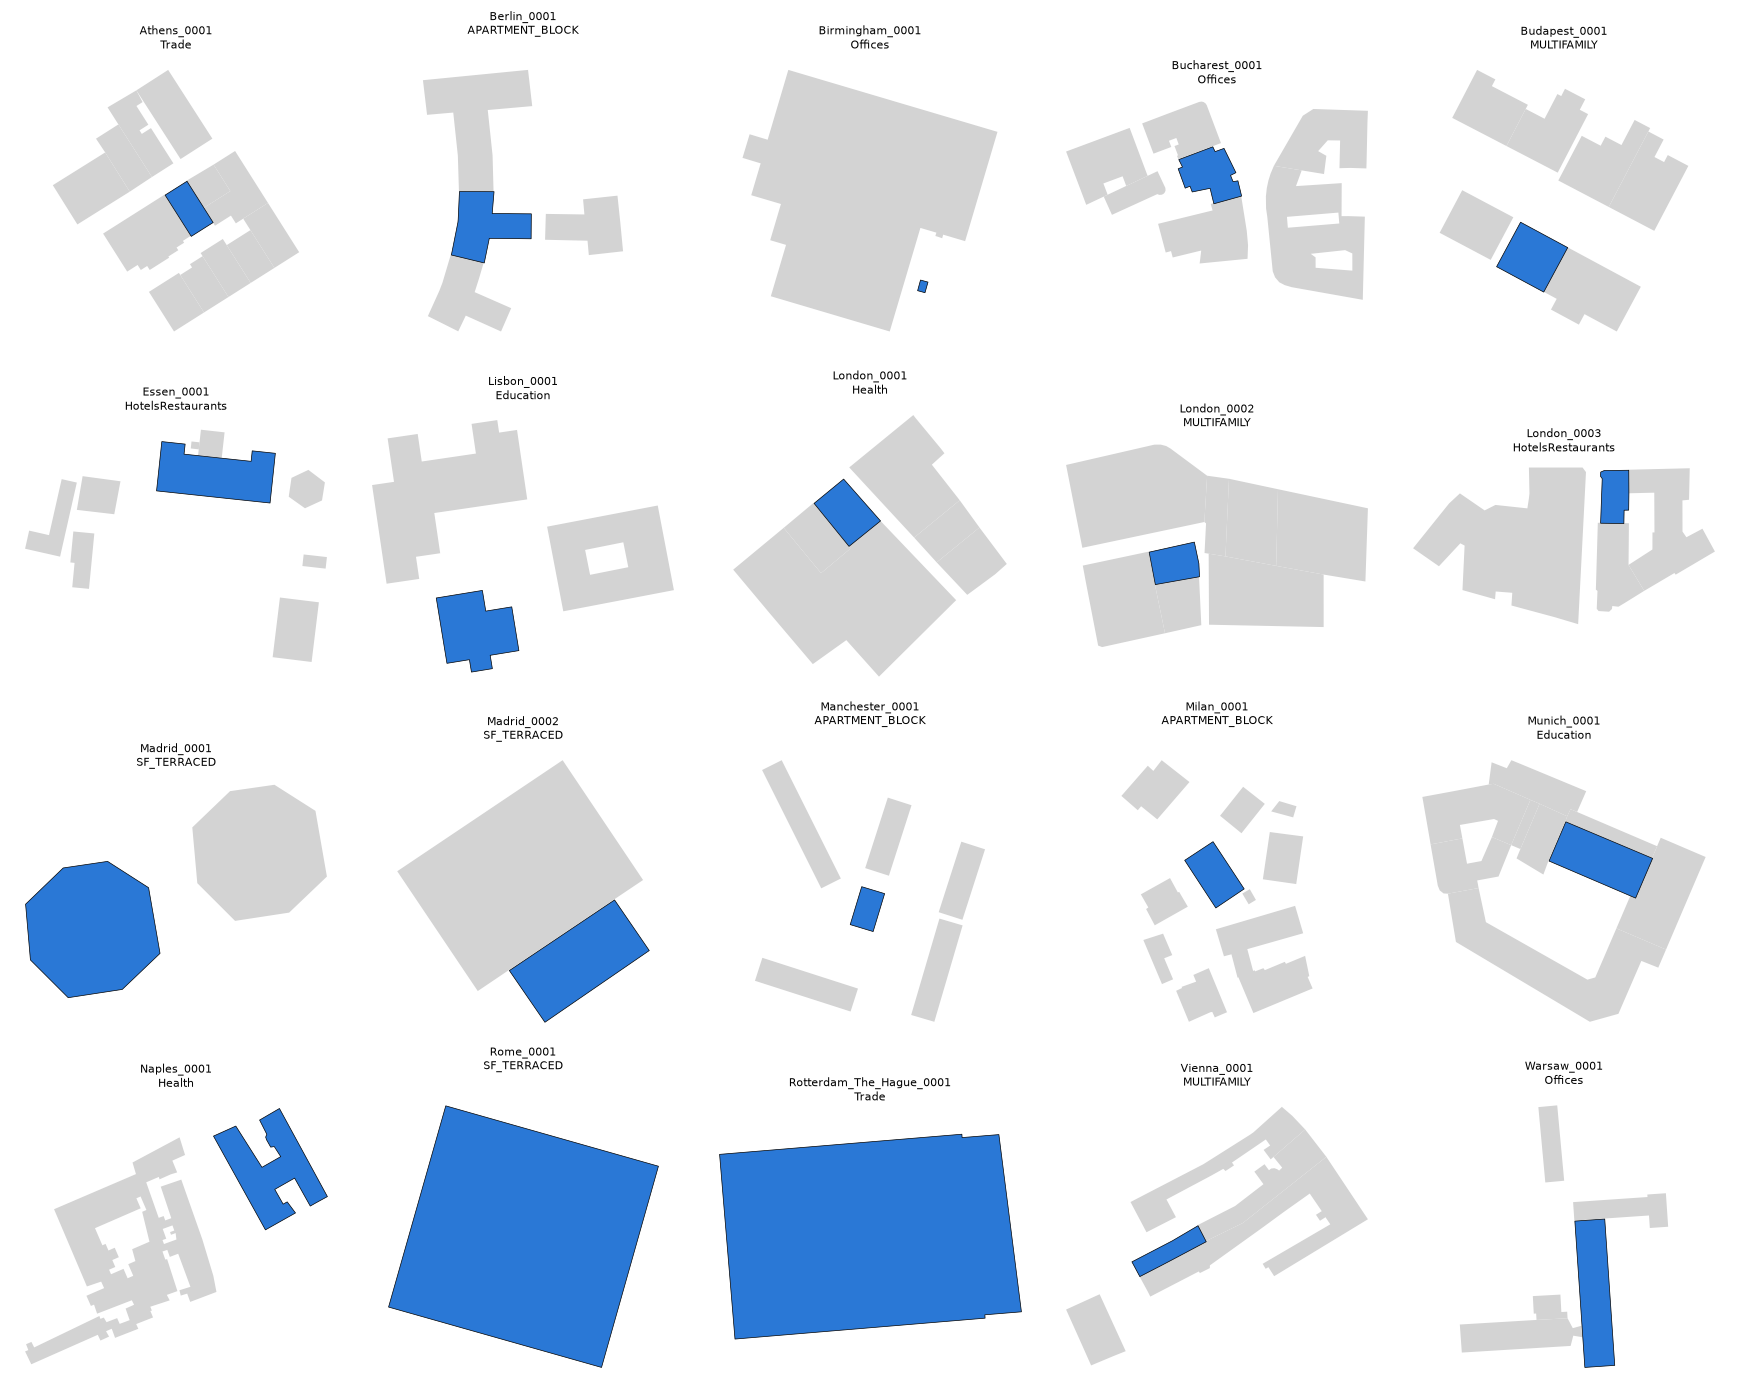

In [7]:
if ENABLE_QA_PLOTS:
    preview_ids = buildings_gdf["sample_id"].head(QA_PLOT_SAMPLES).tolist()
    type_by_id = buildings_gdf.set_index("sample_id")["building_type"].to_dict()
    GHSL_gridplot(
        [
            {"name": "neighbours", "role": "neighbor", "color": "#d3d3d3",
             "gdf": neighbors_gdf[neighbors_gdf["sample_id"].isin(preview_ids)],
             "id_col": "sample_id", "geometry_col": neighbors_gdf.geometry.name},
            {"name": "buildings", "role": "main", "color": "#2a78d6",
             "gdf": buildings_gdf[buildings_gdf["sample_id"].isin(preview_ids)],
             "id_col": "sample_id", "geometry_col": buildings_gdf.geometry.name},
        ],
        ids=preview_ids,
        ncols=QA_PLOT_COLUMNS,
        figsize_scale=3.5,
        title_fn=lambda sample_id, _: f"{sample_id}\n{type_by_id.get(sample_id, '')}",
    )
else:
    print("QA plot disabled.")

## Save the sample

City metadata is not repeated here: the later stages read `cities_df.pkl` and `city_assets_df.pkl`
from Stage 1 and join on `city_key`.

**Outputs**

- `data/interim/buildings_gdf.pkl`
- `data/interim/neighbors_gdf.pkl`


In [8]:
BUILDINGS_PKL = INTERIM_DIR / "buildings_gdf.pkl"
NEIGHBORS_PKL = INTERIM_DIR / "neighbors_gdf.pkl"

buildings_gdf.to_pickle(BUILDINGS_PKL)
neighbors_gdf.to_pickle(NEIGHBORS_PKL)

residential = int((buildings_gdf["dataset_kind"] == "residential").sum())
print(f"{display_path(BUILDINGS_PKL)}: {len(buildings_gdf)} buildings "
      f"({residential} residential, {len(buildings_gdf) - residential} non-residential)")
print(f"{display_path(NEIGHBORS_PKL)}: {len(neighbors_gdf)} neighbour geometries")

data/interim/buildings_gdf.pkl: 20 buildings (9 residential, 11 non-residential)
data/interim/neighbors_gdf.pkl: 86 neighbour geometries


## Review the sampled footprints

Some footprints are fine as geometry but wrong as buildings - a courtyard mapped as a block, a row
of garages, a ruin. The app below shows each sample with its neighbours and records the ones to
drop.

**Steps**

1. Run the cell and open the link. The server runs in the background, so the cell returns at once.
2. Select the footprints that should not continue to Stage 4, and save in the app (by pressing Enter).
3. Run the last cell to apply the selection.

Re-running the launch cell restarts the server. The selection is written to
`data/interim/selected_bad_footprint_samples.csv`.


In [9]:
from helpers.review_app import launch, link

FOOTPRINT_REVIEW_CSV = INTERIM_DIR / "selected_bad_footprint_samples.csv"

review_url = launch(
    "scripts.review_apps.serve_footprint_selector",
    buildings_path=BUILDINGS_PKL,
    neighbors_path=NEIGHBORS_PKL,
    csv_path=FOOTPRINT_REVIEW_CSV,
)
print(f"Selections are saved to {display_path(FOOTPRINT_REVIEW_CSV)}")
link(review_url, "Open the footprint review app")

Selections are saved to data/interim/selected_bad_footprint_samples.csv


## Apply the review

Run this after saving in the app. With nothing selected it reports that nothing changed, and it can
be run again whenever more footprints are added to the list.

The selected rows are removed from both artifacts together, and kept in
`data/interim/buildings_footprint_review_removed.pkl` so a removal can be traced later.


In [10]:
from helpers.review_selections import apply_footprint_review_selections

report = apply_footprint_review_selections(
    buildings_path=BUILDINGS_PKL,
    neighbors_path=NEIGHBORS_PKL,
    csv_path=FOOTPRINT_REVIEW_CSV,
    removed_path=INTERIM_DIR / "buildings_footprint_review_removed.pkl",
)

if not report["selected_ids"]:
    print("Nothing is selected for removal; the artifacts are unchanged.")
elif not report["removed_now"]:
    print("Every saved selection had already been applied.")
else:
    print(
        f"Removed {len(report['removed_now'])} footprints and "
        f"{report['removed_neighbor_rows']} neighbour rows; "
        f"{report['active_buildings']} buildings remain."
    )

if report["unknown_ids"]:
    print(f"[WARN] Selected IDs not found in the artifacts: {report['unknown_ids']}")

buildings_gdf = pd.read_pickle(BUILDINGS_PKL)
neighbors_gdf = pd.read_pickle(NEIGHBORS_PKL)


Removed 2 footprints and 1 neighbour rows; 18 buildings remain.
